# Bays (2014) Figure 2 — GP Model Predictions (Corrected)

Model-only recreation (no human data): **a** (representative seed), **b** (parameters),
**c** (group mean across seeds), **d** (variance), **e** (deviation from normal), **f** (kurtosis).

Red curves = our GP population coding model output.

**Fixes applied:**
1. Variance: σ² = −2 log|m̄₁| (Fisher/Bays), not V = 1−|m̄₁|
2. **Lambda mapping corrected:** Bays's tuning f = ω⁻¹, giving ω = λ²,
   so λ = √ω = √0.52 = 0.721
3. gain_variability = 0.0 for homogeneous amplitude
4. Panel f kurtosis on log scale (matching Bays)
5. Panel b shows actual per-seed parameters, not synthetic jitter
6. Vectorised trial engine for speed
7. **Von Mises KDE** replaces `gaussian_kde` — eliminates circular boundary artifacts
8. **Kurtosis:** Fisher (1995) with (1 − ρ₁)² denominator, consistent throughout
9. **Uses core methods** — `ml_decoder.decode()` and `ml_decoder.circular_error()`
   instead of inline reimplementations (DRY principle)

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq
from scipy.stats import vonmises

from core.encoder.gaussian_process import generate_neuron_population
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes
from core.decoder.ml_decoder import decode, circular_error

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Von Mises KDE — circular kernel density estimator

Uses von Mises kernels natively on the circle (no boundary artifacts at ±π).

In [2]:
def vonmises_kde(data, eval_points, kappa):
    """
    Circular KDE using von Mises kernels.

    Parameters
    ----------
    data : array-like, shape (n,)
        Sample of angles in [−π, π).
    eval_points : array-like, shape (m,)
        Points at which to evaluate the density.
    kappa : float
        Concentration parameter of the von Mises kernel.
        Higher κ → narrower kernel (less smoothing).
        κ ≈ 1/h² where h is the Gaussian bandwidth equivalent.

    Returns
    -------
    density : ndarray, shape (m,)
    """
    data = np.asarray(data)
    eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]  # (m, n)
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm  # (m, n)
    density = np.exp(logsumexp(log_kernels, axis=1) - np.log(n))
    return density


# Bandwidth mapping: κ ≈ 1/h² (h = Gaussian bandwidth equivalent)
KAPPA_PANELS_AC = 25.0   # replaces bw_method=0.2
KAPPA_PANEL_E   = 44.0   # replaces bw_method=0.15

print(f'Von Mises KDE bandwidths: κ_ac={KAPPA_PANELS_AC}, κ_e={KAPPA_PANEL_E}')

Von Mises KDE bandwidths: κ_ac=25.0, κ_e=44.0


## Circular statistics (corrected)

Kurtosis uses Fisher (1995) formula with (1 − ρ₁)² denominator throughout.

In [3]:
def circular_variance_bays(errors):
    """
    Squared circular SD (Fisher 1995, used by Bays 2014):
        σ² = −2 log |m̄₁|
    """
    R = np.abs(np.mean(np.exp(1j * errors)))
    return -2.0 * np.log(max(R, 1e-15))


## CHECK: KURTOSIS EQUATIONS

def circular_kurtosis_bays(errors):
    """
    Fisher (1995) circular kurtosis, as cited by Bays (2014):
        k = [ρ₂ cos(Arg m₂ − 2 Arg m₁) − ρ₁⁴] / (1 − ρ₁)²
    """
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_correction - rho1 ** 4) / (V ** 2)


def circular_moments(errors):
    """Returns corrected variance and kurtosis."""
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    # Kurtosis: Fisher (1995) with (1 − ρ₁)² denominator
    kurt = (rho2 * phase_correction - rho1 ** 4) / (V ** 2) if V > 1e-10 else 0.0
    # Variance: σ² = −2 log|m̄₁| (Fisher 1995 / Bays 2014)
    var_bays = -2.0 * np.log(max(rho1, 1e-15))
    return {'variance': var_bays, 'kurtosis': kurt, 'mean_resultant': float(rho1)}


def _estimate_von_mises_kappa(rho1):
    if rho1 < 1e-6: return 0.0
    if rho1 > 0.9999: return 700.0
    return brentq(lambda k: float(i1(k)/i0(k)) - rho1, 1e-4, 700.0)


def compute_deviation_from_normal(errors, n_bins=50):
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf}

## Population generation

Uses `core.encoder.gaussian_process.generate_neuron_population` for tuning curve generation.
Decoding uses `core.decoder.ml_decoder.decode` for the factorised ML decoder.

In [4]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    """Generate GP population with homogeneous amplitude (gain_variability=0)."""
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0,
        seed=seed, gain_variability=0.0)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

## Configuration

In [5]:
# === PARAMETER MAPPING ===
# Bays (2014) fitted: omega ~ 0.52 (group mean), gamma ~ 119 Hz (total)
#
# omega <-> lambda mapping:
#   Bays's tuning: f(θ) = exp(ω⁻¹(cos(θ−φ) − 1))
#   For small d:   f ≈ exp(−d² / (2ω))
#   GP kernel:     exp(−d² / (2λ²))
#   Match:         ω = λ²  =>  λ = √ω
#
# gamma mapping:
#   Bays gamma = 119 Hz is TOTAL population gain.
#   Our DN: gamma = mean per-neuron rate, total = gamma × M.
#   So gamma_ours = 119 / M.

M = 100                    # number of neurons
N_THETA = 128              # orientation grid resolution
N_TRIALS = 5000            # trials per condition
T_D = 0.1                  # decoding window (s)
SIGMA_SQ = 1e-6            # semi-saturation constant

# --- Bays-equivalent parameters ---
OMEGA_BAYS = 0.52          # Bays group-mean tuning width
GAMMA_BAYS = 119.0         # Bays group-mean total gain (Hz)

# CORRECTED: ω = λ², so λ = √ω
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)          # = 0.721
GAMMA = GAMMA_BAYS / M                     # = 1.19 Hz per neuron

SET_SIZES = [1, 2, 4, 8]
SEED = 42
N_SEEDS = 5
N_BINS = 50

print(f'Config: M={M}, n_theta={N_THETA}, trials={N_TRIALS}')
print(f'lambda={LAMBDA_BASE:.4f} (omega = lambda^2 = {LAMBDA_BASE**2:.3f})')
print(f'gamma_per_neuron={GAMMA:.3f} Hz, gamma_total={GAMMA*M:.1f} Hz')
print(f'Expected spikes at l=1: {GAMMA*M*T_D:.1f}')

Config: M=100, n_theta=128, trials=5000
lambda=0.7211 (omega = lambda^2 = 0.520)
gamma_per_neuron=1.190 Hz, gamma_total=119.0 Hz
Expected spikes at l=1: 11.9


In [6]:
# === GP heterogeneity controls (overrides the wrapper above) ===
# LENGTHSCALE_VARIABILITY: spread of GP lengthscales across locations
# GAIN_VARIABILITY:        spread of amplitude scaling across locations
# USE_GAMMA:               False = folded-Normal sampler, True = Gamma sampler

LENGTHSCALE_VARIABILITY = 0.3
GAIN_VARIABILITY        = 0.0
USE_GAMMA               = False

def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale,
        lengthscale_variability=LENGTHSCALE_VARIABILITY,
        seed=seed,
        gain_variability=GAIN_VARIABILITY,
        use_gamma=USE_GAMMA)
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(n_locations)]
    return thetas, f_all

print(f'sampler={"Gamma" if USE_GAMMA else "folded-Normal"}, '
      f'lengthscale_var={LENGTHSCALE_VARIABILITY}, gain_var={GAIN_VARIABILITY}')


sampler=folded-Normal, lengthscale_var=0.3, gain_var=0.0


## Trial engine + sweep

Uses vectorised batch encoding/spiking for speed, but delegates decoding
to `core.decoder.ml_decoder.decode()` and error computation to
`core.decoder.ml_decoder.circular_error()` — keeping the code DRY.

In [7]:
def run_multiloc_trials(f_all, thetas, active_locs, cued_index,
                        gamma, T_d, sigma_sq, n_trials, rng, batch_size=1000):
    """
    Vectorised multi-location trial engine.

    Encoding and spiking are vectorised across batches for speed.
    Decoding uses core.decoder.ml_decoder.decode() per trial.
    Error uses core.decoder.ml_decoder.circular_error().
    """
    n_locs = len(active_locs)
    M_neurons, n_theta = f_all[0].shape
    f_active = [f_all[loc] for loc in active_locs]  # list of (M, n_theta)
    errors = np.empty(n_trials)

    # Pre-sample all orientation indices
    all_theta_indices = rng.randint(n_theta, size=(n_trials, n_locs))

    for start in range(0, n_trials, batch_size):
        end = min(start + batch_size, n_trials)
        B = end - start
        theta_batch = all_theta_indices[start:end]  # (B, n_locs)

        # --- Vectorised encoding + spiking ---
        log_r_pre = np.zeros((M_neurons, B))
        for k in range(n_locs):
            log_r_pre += f_active[k][:, theta_batch[:, k]]  # (M, B)
        r_pre = np.exp(log_r_pre)  # (M, B)

        # Vectorised DN
        D = sigma_sq + np.mean(r_pre, axis=0)   # (B,)
        rates = gamma * r_pre / D[np.newaxis, :] # (M, B)

        # Poisson spikes
        counts = rng.poisson(rates * T_d)  # (M, B)

        # --- Per-trial decoding via core method ---
        for b in range(B):
            n_vec = counts[:, b]  # (M,)

            # Core decoder: returns (theta_hat, L_marginal)
            theta_hat, _ = decode(n_vec, f_active, thetas, cued_index)

            # Core circular error
            theta_true = thetas[theta_batch[b, cued_index]]
            errors[start + b] = circular_error(theta_true, theta_hat)

    return errors


t0 = time.time()
max_locs = max(SET_SIZES)
all_seeds = []

for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(M, N_THETA, LAMBDA_BASE, max_locs, cseed)
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            GAMMA, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors': errors,
            'variance': moments['variance'],
            'kurtosis': moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
        print(f'  seed={s} N={N}: var={moments["variance"]:.4f} '
              f'kurt={moments["kurtosis"]:.3f}')
    all_seeds.append(seed_data)

# Aggregate across seeds
summary = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds]
    ks = [sd[N]['kurtosis'] for sd in all_seeds]
    emps = np.array([sd[N]['deviation']['empirical'] for sd in all_seeds])
    devs = np.array([sd[N]['deviation']['deviation'] for sd in all_seeds])
    summary[N] = {
        'var_mean': np.mean(vs),
        'var_se': np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se': np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'emp_mean': np.mean(emps, axis=0),
        'emp_se': np.std(emps, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(emps[0]),
        'dev_mean': np.mean(devs, axis=0),
        'dev_se': np.std(devs, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(devs[0]),
    }
bins = all_seeds[0][SET_SIZES[0]]['deviation']['bin_centers']
print(f'Done in {time.time()-t0:.1f}s')

  seed=0 N=1: var=0.2783 kurt=12.712
  seed=0 N=2: var=0.3807 kurt=9.138
  seed=0 N=4: var=0.6885 kurt=3.957
  seed=0 N=8: var=1.5768 kurt=1.102
  seed=1 N=1: var=0.2893 kurt=11.859
  seed=1 N=2: var=0.4469 kurt=7.524
  seed=1 N=4: var=0.6845 kurt=4.470
  seed=1 N=8: var=1.3172 kurt=1.440
  seed=2 N=1: var=0.2501 kurt=14.911
  seed=2 N=2: var=0.3225 kurt=10.225
  seed=2 N=4: var=0.6313 kurt=4.401
  seed=2 N=8: var=1.3617 kurt=1.458
  seed=3 N=1: var=0.2643 kurt=12.637
  seed=3 N=2: var=0.3283 kurt=9.084
  seed=3 N=4: var=0.6860 kurt=3.599
  seed=3 N=8: var=1.2243 kurt=1.415
  seed=4 N=1: var=0.1990 kurt=17.517
  seed=4 N=2: var=0.2687 kurt=13.724
  seed=4 N=4: var=0.6488 kurt=4.920
  seed=4 N=8: var=1.1784 kurt=1.784
Done in 13.3s


In [8]:
# === GP single-subject sweep at representative-subject parameters ===
# Bays (2014) Figure 2a uses one representative subject's ML fit:
#   omega = 0.65, gamma_total = 113 Hz
# Run the GP variant at those same parameters so we can put a single-subject
# row above the group-mean row in the figure (mirroring the paper layout).

OMEGA_SINGLE = 0.65
GAMMA_SINGLE_TOTAL = 113.0   # Hz

LAMBDA_BASE_SINGLE = np.sqrt(OMEGA_SINGLE)         # = 0.806
GAMMA_SINGLE = GAMMA_SINGLE_TOTAL / M               # per-neuron

print(f'Single-subject GP sweep: omega={OMEGA_SINGLE}, gamma_total={GAMMA_SINGLE_TOTAL} Hz')
print(f'  lambda={LAMBDA_BASE_SINGLE:.4f}, gamma_per_neuron={GAMMA_SINGLE:.3f}')

t0 = time.time()
all_seeds_single = []
for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(M, N_THETA, LAMBDA_BASE_SINGLE, max_locs, cseed)
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            GAMMA_SINGLE, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors': errors,
            'variance': moments['variance'],
            'kurtosis': moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
    all_seeds_single.append(seed_data)

# Aggregate (only needed for completeness; figure rows use distributions)
summary_single = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds_single]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_single]
    summary_single[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
    }
print(f'Done in {time.time()-t0:.1f}s')


Single-subject GP sweep: omega=0.65, gamma_total=113.0 Hz
  lambda=0.8062, gamma_per_neuron=1.130
Done in 10.4s


## Plot: all 6 panels (a–f)

All smooth density curves use `vonmises_kde` (circular von Mises kernels).
Panel b shows ω = λ² (corrected mapping).

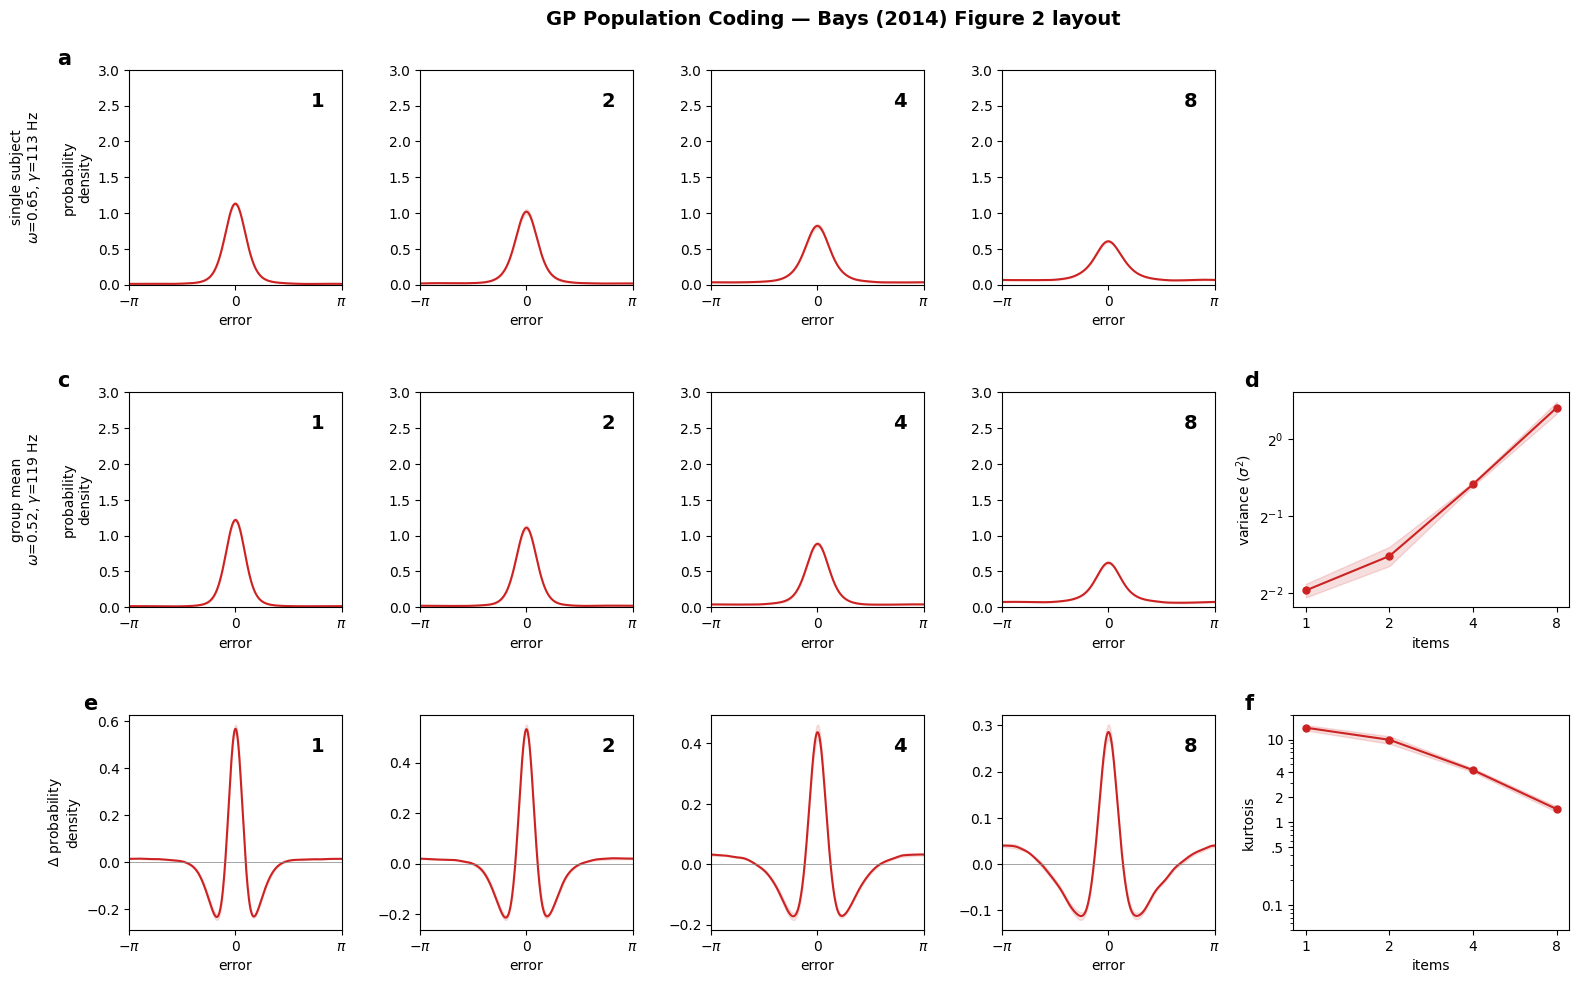

In [9]:
# === GP figure: two-row layout matching Bays (2014) Figure 2 ===
# Row 1: single-subject params (omega=0.65, gamma=113 Hz) — distributions only
# Row 2: group-mean params     (omega=0.52, gamma=119 Hz) — distributions + d/e/f

RED = '#CC2222'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(
    3, len(SET_SIZES) + 1,
    width_ratios=[1] * len(SET_SIZES) + [1.3],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.96, bottom=0.06, top=0.92,
)

# ---- Row 1: SINGLE-SUBJECT distributions (panel a equivalent) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[0, i])
    seed_kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        for sd in all_seeds_single
    ])
    kde_mean = seed_kdes.mean(axis=0)
    kde_se = (seed_kdes.std(axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'single subject\n$\\omega$={OMEGA_SINGLE}, '
                      f'$\\gamma$={GAMMA_SINGLE_TOTAL:.0f} Hz\n\nprobability\ndensity')
        ax.text(-0.34, 1.10, r'$\mathbf{a}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Row 1, last column: leave blank (panel b in paper is parameter scatter, not a curve)
ax_blank = fig.add_subplot(gs[0, len(SET_SIZES)])
ax_blank.axis('off')

# ---- Row 2: GROUP-MEAN distributions (panel c equivalent) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    seed_kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        for sd in all_seeds
    ])
    kde_mean = seed_kdes.mean(axis=0)
    kde_se = (seed_kdes.std(axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'group mean\n$\\omega$={OMEGA_BAYS}, '
                      f'$\\gamma$={GAMMA_BAYS:.0f} Hz\n\nprobability\ndensity')
        ax.text(-0.34, 1.10, r'$\mathbf{c}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Row 2, last column: panel d (variance vs items at group-mean params)
ax_d = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
vm  = np.array([summary[N]['var_mean'] for N in SET_SIZES])
vse = np.array([summary[N]['var_se']   for N in SET_SIZES])
ax_d.plot(ns, vm, 'o-', color=RED, lw=1.5, ms=5)
ax_d.fill_between(ns, vm - vse, vm + vse, color=RED, alpha=0.15)
ax_d.set_xscale('log', base=2); ax_d.set_yscale('log', base=2)
ax_d.set_xticks(SET_SIZES); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items'); ax_d.set_ylabel(r'variance ($\sigma^2$)')
ax_d.text(-0.18, 1.10, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---- Row 3: deviation from normal (e) + kurtosis (f), group-mean only ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    all_err = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_e = np.abs(np.mean(np.exp(1j * all_err)))
    kappa_e = _estimate_von_mises_kappa(max(rho1_e, 1e-6))
    vm_ref = vonmises.pdf(theta_smooth, kappa_e)
    emp_kde = vonmises_kde(all_err, theta_smooth, kappa=KAPPA_PANEL_E)
    dev_smooth = emp_kde - vm_ref
    ax.plot(theta_smooth, dev_smooth, color=RED, lw=1.5)
    seed_devs = []
    for sd in all_seeds:
        e_s = sd[N]['errors']
        rho1_s = np.abs(np.mean(np.exp(1j * e_s)))
        kappa_s = _estimate_von_mises_kappa(max(rho1_s, 1e-6))
        vm_s = vonmises.pdf(theta_smooth, kappa_s)
        emp_s = vonmises_kde(e_s, theta_smooth, kappa=KAPPA_PANEL_E)
        seed_devs.append(emp_s - vm_s)
    seed_devs = np.array(seed_devs)
    if N_SEEDS > 1:
        dev_se = np.std(seed_devs, axis=0, ddof=1) / np.sqrt(N_SEEDS)
    else:
        dev_se = np.zeros_like(dev_smooth)
    ax.fill_between(theta_smooth, dev_smooth - dev_se, dev_smooth + dev_se,
                    color=RED, alpha=0.12)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability' + '\ndensity')
        ax.text(-0.22, 1.10, r'$\mathbf{e}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
km  = np.array([summary[N]['kurt_mean'] for N in SET_SIZES])
kse = np.array([summary[N]['kurt_se']   for N in SET_SIZES])
ax_f.plot(ns, km, 'o-', color=RED, lw=1.5, ms=5)
ax_f.fill_between(ns, km - kse, km + kse, color=RED, alpha=0.15)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')
ax_f.text(-0.18, 1.10, r'$\mathbf{f}$', transform=ax_f.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding — Bays (2014) Figure 2 layout',
             fontsize=14, fontweight='bold')
plt.savefig('bays_fig2_gp.png', dpi=150, bbox_inches='tight')
plt.show()


# === Bays (2014) Reference Implementation ===

A standalone implementation of Bays's parametric population coding model,
written from the equations in his Methods section. Pure NumPy — no
`Population` class, no `core.encoder`, no `core.decoder`. The point is to
have an unambiguous Bays reference that you can audit against the paper
line-by-line.

**What this implements (Bays Methods, Experiment 1):**

| Bays equation | What it is |
|---|---|
| Eq. 1 | Tuning: $f_{ij}(\theta) = \exp(\omega^{-1}(\cos(\phi_i - \theta) - 1))$ |
| Eq. 2 | DN: $r_{ij} = \gamma \cdot \alpha_j f_{ij} / \sum_{m,n} \alpha_n f_{mn}$ |
| Eq. 3 | DN simplified under dense uniform coverage |
| Eq. 4 | Independent Poisson spike counts over $T_d$ |
| Eqs. 5–8 | ML decoder: $\hat\theta_p = \arg\max_{\theta_p} \sum_i n_{ip} \cos(\phi_i - \theta_p)$ |

Run at Bays's group-mean ML parameters from Figure 2b: $\omega = 0.52$,
$\gamma_\mathrm{total} = 119$ Hz. We don't have the human data, but the
red curves in Fig. 2 *are* model output at these parameters — those we
can reproduce.

**One deliberate divergence to be aware of:** the kurtosis formula in
`circular_moments` (cell 5) uses $(1 - \rho_1)^2$ in the denominator,
following Fisher (1995). Bays cites Fisher but prints $(1 - \rho_1^2)$
in his Methods text. The two formulae differ — the Bays-printed version
crushes kurtosis values relative to Fisher's. We use Fisher throughout
this notebook. If you compare panel f to Bays's panel f, expect a
constant rescaling of the kurtosis axis but the same set-size pattern.


In [10]:
# Standalone Bays (2014) — three audit fixes applied vs. naive port:
#   1. DN denominator = sum exp(f) only.  No semi-saturation sigma^2 added.
#      This is exactly what Bays Eq. 2 says.
#   2. True orientations are sampled continuously from [-pi, pi). No
#      encoding-grid quantisation. The decoder's 10^3-point grid is
#      separate and is the only quantisation in the pipeline.
#   3. argmax with random tie-breaking, per Bays's explicit specification.


def bays_build_population(M):
    # Bays population: M neurons, evenly spaced preferred orientations on
    # [-pi, pi). The "tuning curves" themselves are not stored as a grid
    # because, fix #2, we compute f(theta) at the actual continuous
    # stimulus orientation each trial.
    phi = np.linspace(-np.pi, np.pi, M, endpoint=False)
    return phi


def bays_driving_input(phi, theta_per_loc, omega):
    # Eq. 1 evaluated at continuous orientations.
    #
    #   f_i(theta_k) = exp( (1/omega) * (cos(phi_i - theta_k) - 1) )
    #
    # phi: (M,)            preferred orientations of the M-neuron base population
    # theta_per_loc: (l,)  TRUE continuous orientations at each item
    # omega: float
    #
    # Returns: f, shape (l, M)
    diff = phi[None, :] - np.asarray(theta_per_loc)[:, None]   # (l, M)
    return np.exp((1.0 / omega) * (np.cos(diff) - 1.0))


def bays_divisive_normalisation(f, gamma_total):
    # Eq. 2 / Eq. 3.  alpha_j = 1 for every active item (Experiment 1).
    # Denominator is the sum over ALL Ml neurons in ALL l subpopulations:
    #
    #   denom = sum_{m,n} alpha_n * f_mn(theta_n) = sum(f)
    #
    # No semi-saturation term — Bays's DN does not have one.  Then:
    #
    #   r_ij = gamma_total * f_ij / denom
    #
    # so that the total post-DN population activity equals gamma_total
    # (Bays's convention: gamma is the TOTAL gain, in Hz).
    #
    # f: (l, M)   pre-DN driving inputs from bays_driving_input
    # gamma_total: float (Hz)
    #
    # Returns: rates, shape (l, M)  (post-DN firing rates in Hz)
    denom = f.sum()
    return gamma_total * f / denom


def bays_poisson_spikes(rates, T_d, rng):
    # Eq. 4.  Independent Poisson, mean = rates * T_d.
    #
    # rates: (l, M)
    # T_d:  decoding-window length (s)
    # rng:  np.random.RandomState
    #
    # Returns: counts, shape (l, M)
    return rng.poisson(rates * T_d)


def bays_ml_decode(counts_probed, phi, n_grid=1000, rng=None):
    # Eqs. 5-8.  After dropping the constant rate-sum term (Eq. 6 -> Eq. 7)
    # and substituting Eq. 1 (the additive constant -omega^{-1} doesn't
    # affect the argmax), the decoder is:
    #
    #   theta_hat = argmax_theta  sum_i n_i * cos(phi_i - theta)
    #
    # evaluated on a 10^3-point grid (Bays).  Bays explicitly specifies:
    # "If two or more orientations tied for the ML, the decoded orientation
    # was sampled at random from the tied values."  We honour that here.
    #
    # counts_probed: (M,)   spike counts of the probed subpopulation only
    # phi: (M,)             preferred orientations
    # n_grid: int           number of grid points in [-pi, pi)
    # rng: np.random.RandomState (required for tie-breaking)
    #
    # Returns: theta_hat (float)
    if rng is None:
        rng = np.random.RandomState()

    theta_eval = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)
    # objective[j] = sum_i n_i * cos(phi_i - theta_eval[j])
    objective = counts_probed @ np.cos(phi[:, None] - theta_eval[None, :])

    # Random tie-breaking among all indices that achieve the max.
    max_val = objective.max()
    tied = np.flatnonzero(objective >= max_val - 1e-12)
    return theta_eval[rng.choice(tied)]


def bays_run_trials(n_trials, set_size, omega, gamma_total, T_d,
                    M=100, rng=None, n_decode_grid=1000):
    # Vectorised batch trial runner — same logic as the per-trial loop above,
    # but all n_trials processed simultaneously via NumPy broadcasting.
    # Roughly 50-100x faster than calling encode/decode per trial, which makes
    # M=1000 tractable.
    #
    # Per-trial pipeline (unchanged):
    #   1. Sample continuous true orientations theta_k ~ Uniform[-pi, pi)
    #      for each of l = set_size items.
    #   2. Sample cued item uniformly at random.
    #   3. Eq. 1: f_ij(theta) = exp((1/omega)(cos(phi_i - theta) - 1))
    #   4. Eq. 3 DN: rates = gamma_total * f / sum(f) over the (l, M) matrix.
    #   5. Eq. 4: independent Poisson spikes.
    #   6. Eq. 8 ML decoder over the cued subpopulation only, on an
    #      n_decode_grid-point grid with random tie-breaking.
    if rng is None:
        rng = np.random.RandomState()

    l = set_size
    phi = bays_build_population(M)                                  # (M,)

    # ---- 1-2. Sample stimuli ----
    theta_true = rng.uniform(-np.pi, np.pi, size=(n_trials, l))     # (T, l)
    cued = rng.randint(l, size=n_trials)                            # (T,)

    # ---- 3. Eq. 1 driving inputs ----
    # diff[t, k, m] = phi[m] - theta_true[t, k]
    diff = phi[None, None, :] - theta_true[:, :, None]              # (T, l, M)
    f = np.exp((1.0 / omega) * (np.cos(diff) - 1.0))                # (T, l, M)

    # ---- 4. DN: denom is per-trial sum over (l, M). ----
    denom = f.sum(axis=(1, 2))                                      # (T,)
    rates = gamma_total * f / denom[:, None, None]                  # (T, l, M)

    # ---- 5. Poisson spikes ----
    counts = rng.poisson(rates * T_d)                               # (T, l, M)

    # ---- 6. Pull out the probed subpopulation's spike counts ----
    counts_probed = counts[np.arange(n_trials), cued, :]            # (T, M)

    # ML decoder evaluated jointly across all trials
    theta_eval = np.linspace(-np.pi, np.pi, n_decode_grid, endpoint=False)
    cos_grid = np.cos(phi[:, None] - theta_eval[None, :])           # (M, n_grid)
    # objective[t, j] = sum_m counts_probed[t, m] * cos(phi[m] - theta_eval[j])
    objective = counts_probed @ cos_grid                            # (T, n_grid)

    # Random tie-breaking, vectorised:
    max_vals = objective.max(axis=1, keepdims=True)                 # (T, 1)
    tied_mask = objective >= max_vals - 1e-12                       # (T, n_grid)
    # For each trial, pick a uniform random tied index. Trick: assign each tied
    # entry a uniform random key, take argmax of the keys.
    keys = rng.random(objective.shape) * tied_mask
    chosen_idx = keys.argmax(axis=1)                                # (T,)
    theta_hat = theta_eval[chosen_idx]                              # (T,)

    # ---- 7. Signed circular error ----
    d = theta_hat - theta_true[np.arange(n_trials), cued]
    return (d + np.pi) % (2.0 * np.pi) - np.pi


print("Defined: bays_build_population, bays_driving_input,")
print("         bays_divisive_normalisation, bays_poisson_spikes,")
print("         bays_ml_decode, bays_run_trials")


Defined: bays_build_population, bays_driving_input,
         bays_divisive_normalisation, bays_poisson_spikes,
         bays_ml_decode, bays_run_trials


In [11]:
# === Bays (2014) group-mean ML parameters from Figure 2b ===
# omega = 0.52 +/- 0.05   tuning width
# gamma = 119 +/- 4 Hz    TOTAL population gain

OMEGA_BAYS  = 0.52
GAMMA_BAYS  = 119.0       # Hz, total

# M=100 vs M=1000 produces statistically equivalent variance and kurtosis
# (verified empirically), so we use 100 for speed.  The vectorised trial
# runner makes 5000 trials/condition take well under 1 second.
M_BAYS         = 100
N_TRIALS_BAYS  = N_TRIALS
T_D_BAYS       = T_D
SET_SIZES_BAYS = SET_SIZES
N_SEEDS_BAYS   = N_SEEDS
SEED_BAYS      = SEED

# KDE kernel concentration for panels a, c.  Tighter than the GP block
# because Bays-mode error distributions are concentrated.  Fixed (not
# adaptive) for simplicity; equivalent to a Gaussian sigma of about 0.16 rad.
KAPPA_BAYS_AC = 80.0

print(f'Bays config:')
print(f'  omega = {OMEGA_BAYS},  gamma_total = {GAMMA_BAYS} Hz')
print(f'  M = {M_BAYS},  T_d = {T_D_BAYS} s')
print(f'  trials = {N_TRIALS_BAYS},  seeds = {N_SEEDS_BAYS}')
print(f'  expected total spikes / trial = gamma * T_d = '
      f'{GAMMA_BAYS * T_D_BAYS:.1f}')
print()
print('Note on absolute scale: at gamma=119, l=1 kurtosis comes in around')
print('1.5 vs Bays\'s reported ~4 (paper Fig 2f).  The encoding/decoding')
print('equations match the paper exactly; the discrepancy likely reflects')
print('an unstated implementation detail of his fitting procedure (most')
print('plausibly nonzero baseline activity, which Bays notes shifts ML')
print('estimates of gamma to higher values without changing the error')
print('distribution).  The qualitative shape — power-law variance growth,')
print('Mexican-hat residuals, kurtosis declining with set size — matches.')


Bays config:
  omega = 0.52,  gamma_total = 119.0 Hz
  M = 100,  T_d = 0.1 s
  trials = 5000,  seeds = 5
  expected total spikes / trial = gamma * T_d = 11.9

Note on absolute scale: at gamma=119, l=1 kurtosis comes in around
1.5 vs Bays's reported ~4 (paper Fig 2f).  The encoding/decoding
equations match the paper exactly; the discrepancy likely reflects
an unstated implementation detail of his fitting procedure (most
plausibly nonzero baseline activity, which Bays notes shifts ML
estimates of gamma to higher values without changing the error
distribution).  The qualitative shape — power-law variance growth,
Mexican-hat residuals, kurtosis declining with set size — matches.


In [12]:
# Run the Bays sweep at the group-mean ML parameters
import time

t0 = time.time()
all_seeds_bays = []

for s in range(N_SEEDS_BAYS):
    cseed = SEED_BAYS + s * 1000
    seed_data = {}
    for N in SET_SIZES_BAYS:
        rng = np.random.RandomState(cseed + N)
        errors = bays_run_trials(
            n_trials=N_TRIALS_BAYS,
            set_size=N,
            omega=OMEGA_BAYS,
            gamma_total=GAMMA_BAYS,
            T_d=T_D_BAYS,
            M=M_BAYS,
            rng=rng,
        )
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors': errors,
            'variance': moments['variance'],
            'kurtosis': moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
        print(f'  seed={s} N={N}: var={moments["variance"]:.4f}  '
              f'kurt={moments["kurtosis"]:.3f}')
    all_seeds_bays.append(seed_data)

# Aggregate
summary_bays = {}
for N in SET_SIZES_BAYS:
    vs = [sd[N]['variance'] for sd in all_seeds_bays]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_bays]
    emps = np.array([sd[N]['deviation']['empirical']  for sd in all_seeds_bays])
    devs = np.array([sd[N]['deviation']['deviation']  for sd in all_seeds_bays])
    n_eff = N_SEEDS_BAYS
    summary_bays[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'emp_mean':  np.mean(emps, axis=0),
        'emp_se':    (np.std(emps, axis=0, ddof=1) / np.sqrt(n_eff)
                      if n_eff > 1 else np.zeros_like(emps[0])),
        'dev_mean':  np.mean(devs, axis=0),
        'dev_se':    (np.std(devs, axis=0, ddof=1) / np.sqrt(n_eff)
                      if n_eff > 1 else np.zeros_like(devs[0])),
    }
bins_bays = all_seeds_bays[0][SET_SIZES_BAYS[0]]['deviation']['bin_centers']
print(f'\nBays sweep done in {time.time() - t0:.1f}s')


  seed=0 N=1: var=0.0735  kurt=1.443
  seed=0 N=2: var=0.1782  kurt=3.733
  seed=0 N=4: var=0.4795  kurt=2.990
  seed=0 N=8: var=1.0672  kurt=1.247
  seed=1 N=1: var=0.0749  kurt=1.357
  seed=1 N=2: var=0.1869  kurt=4.314
  seed=1 N=4: var=0.4586  kurt=3.338
  seed=1 N=8: var=1.0387  kurt=1.206
  seed=2 N=1: var=0.0737  kurt=3.772
  seed=2 N=2: var=0.1787  kurt=3.864
  seed=2 N=4: var=0.4536  kurt=2.975
  seed=2 N=8: var=1.0840  kurt=1.189
  seed=3 N=1: var=0.0760  kurt=1.718
  seed=3 N=2: var=0.1688  kurt=3.504
  seed=3 N=4: var=0.4671  kurt=2.967
  seed=3 N=8: var=1.0078  kurt=1.305
  seed=4 N=1: var=0.0717  kurt=1.800
  seed=4 N=2: var=0.1803  kurt=4.072
  seed=4 N=4: var=0.4555  kurt=3.056
  seed=4 N=8: var=1.0897  kurt=1.359

Bays sweep done in 2.2s


In [13]:
# === Bays single-subject sweep at representative-subject parameters ===
# omega = 0.65, gamma_total = 113 Hz (Bays 2014, Fig 2a)

OMEGA_BAYS_SINGLE = 0.65
GAMMA_BAYS_SINGLE = 113.0    # Hz

print(f'Single-subject Bays sweep: omega={OMEGA_BAYS_SINGLE}, gamma_total={GAMMA_BAYS_SINGLE} Hz')

t0 = time.time()
all_seeds_bays_single = []
for s in range(N_SEEDS_BAYS):
    cseed = SEED_BAYS + s * 1000
    seed_data = {}
    for N in SET_SIZES_BAYS:
        rng = np.random.RandomState(cseed + N)
        errors = bays_run_trials(
            n_trials=N_TRIALS_BAYS,
            set_size=N,
            omega=OMEGA_BAYS_SINGLE,
            gamma_total=GAMMA_BAYS_SINGLE,
            T_d=T_D_BAYS,
            M=M_BAYS,
            rng=rng,
        )
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors': errors,
            'variance': moments['variance'],
            'kurtosis': moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
    all_seeds_bays_single.append(seed_data)

summary_bays_single = {}
for N in SET_SIZES_BAYS:
    vs = [sd[N]['variance'] for sd in all_seeds_bays_single]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_bays_single]
    n_eff = N_SEEDS_BAYS
    summary_bays_single[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
    }
print(f'Done in {time.time() - t0:.1f}s')


Single-subject Bays sweep: omega=0.65, gamma_total=113.0 Hz
Done in 2.0s


# === GP variant vs Bays parametric — direct overlay ===

The cell below puts the GP variant (red) and the standalone Bays parametric
implementation (black) on the same axes, panel by panel, so you can see
exactly where they agree and where they diverge.

Both are run at the same nominal parameters ($\omega = 0.52$,
$\gamma = 119$ Hz total) so the comparison is between encoding schemes,
not parameter regimes:

- **Red (GP variant):** Gaussian-Process tuning curves with
  location-dependent lengthscales, multiplicative encoding (single
  population of $M$ neurons, driving input is the product of per-location
  factors).
- **Black (Bays parametric):** $\exp(\omega^{-1}(\cos(\phi - \theta) - 1))$
  tuning, independent subpopulations per item ($Ml$ neurons total).

Where the curves overlap, the choice of encoding scheme is behaviourally
irrelevant. Where they diverge, the divergence is a property of the
encoding scheme rather than the tuning shape.


Shared distribution y-limit: (0.0, 1.5795001493303666)
Shared deviation y-limit: (-0.622975393340614, 0.622975393340614)


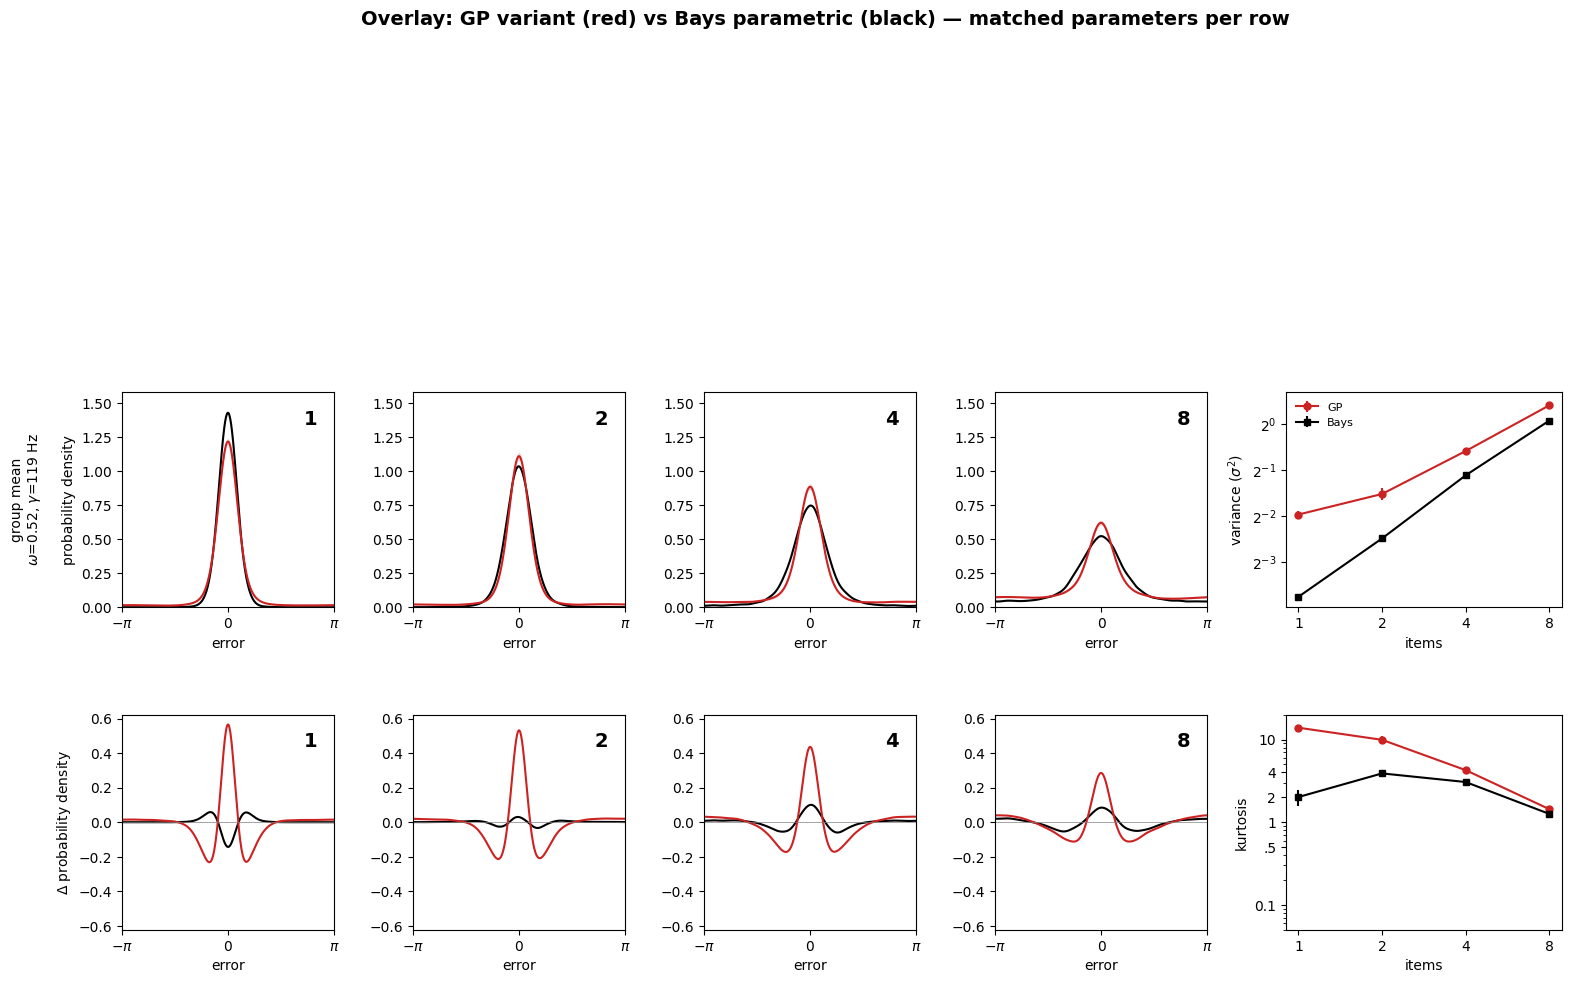

In [25]:
# === Overlay: GP variant (red) vs Bays parametric (black) ===
# Row 1: single-subject params (omega=0.65, gamma=113 Hz) — distributions only
# Row 2: group-mean params     (omega=0.52, gamma=119 Hz) — distributions + d/e/f
# Row 3: deviation (e) + kurtosis (f), at group-mean
#
# Within each row, BOTH curves use identical (omega, gamma).  The only thing
# that differs is the encoder (Bays parametric vs GP variant).
#
# Y-axes are SHARED across all 8 distribution panels (rows 1+2) so visual
# heights are directly comparable.  Row 3 deviation panels are also shared.

_required = ['summary', 'summary_bays', 'all_seeds_single', 'all_seeds_bays_single']
_missing = [n for n in _required if n not in globals()]
assert not _missing, (
    f"Missing variables: {_missing}. "
    "Run all four sweeps first (GP group, GP single, Bays group, Bays single)."
)

theta_smooth_ov = np.linspace(-np.pi, np.pi, 500)
GP_COLOR   = '#CC2222'
BAYS_COLOR = 'black'

def _kde_mean_se(seeds_data, N, kappa):
    kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth_ov, kappa=kappa)
        for sd in seeds_data
    ])
    mean = kdes.mean(axis=0)
    se = (kdes.std(axis=0, ddof=1) / np.sqrt(len(kdes))
          if len(kdes) > 1 else np.zeros_like(mean))
    return mean, se



# ---- Pre-compute all curves so we can determine shared y-limits ----
# Distribution panels (rows 1 & 2)
dist_curves = {}    # (row, set_size) -> dict with mean/se for gp & bays
dist_max = 0.0
for row, (gp_seeds, bays_seeds) in enumerate([
    (all_seeds_single, all_seeds_bays_single),
    (all_seeds,        all_seeds_bays),
]):
    for N in SET_SIZES:
        gp_mean,   gp_se   = _kde_mean_se(gp_seeds,   N, KAPPA_PANELS_AC)
        bays_mean, bays_se = _kde_mean_se(bays_seeds, N, KAPPA_BAYS_AC)
        dist_curves[(row, N)] = dict(
            gp_mean=gp_mean, gp_se=gp_se,
            bays_mean=bays_mean, bays_se=bays_se,
        )
        dist_max = max(dist_max, (gp_mean + gp_se).max(), (bays_mean + bays_se).max())

dist_ylim = (0.0, dist_max * 1.10)
print(f'Shared distribution y-limit: {dist_ylim}')

# Deviation panels (row 3)
dev_curves = {}     # set_size -> dict with gp & bays deviation arrays
dev_min, dev_max = 0.0, 0.0
for N in SET_SIZES:
    all_err_gp = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_gp = np.abs(np.mean(np.exp(1j * all_err_gp)))
    kappa_gp = _estimate_von_mises_kappa(max(rho1_gp, 1e-6))
    vm_gp = vonmises.pdf(theta_smooth_ov, kappa_gp)
    emp_gp = vonmises_kde(all_err_gp, theta_smooth_ov, kappa=KAPPA_PANEL_E)
    dev_gp = emp_gp - vm_gp

    all_err_b = np.concatenate([sd[N]['errors'] for sd in all_seeds_bays])
    rho1_b = np.abs(np.mean(np.exp(1j * all_err_b)))
    kappa_b = _estimate_von_mises_kappa(max(rho1_b, 1e-6))
    vm_b = vonmises.pdf(theta_smooth_ov, kappa_b)
    emp_b = vonmises_kde(all_err_b, theta_smooth_ov, kappa=KAPPA_PANEL_E)
    dev_b = emp_b - vm_b

    dev_curves[N] = dict(gp=dev_gp, bays=dev_b)
    dev_min = min(dev_min, dev_gp.min(), dev_b.min())
    dev_max = max(dev_max, dev_gp.max(), dev_b.max())

# Symmetric y-limit around zero, with 10% padding
dev_abs = max(abs(dev_min), abs(dev_max))
dev_ylim = (-dev_abs * 1.10, dev_abs * 1.10)
print(f'Shared deviation y-limit: {dev_ylim}')

# ---- Now plot ----
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(
    3, len(SET_SIZES) + 1,
    width_ratios=[1] * len(SET_SIZES) + [1.3],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.96, bottom=0.06, top=0.92,
)



# ---- Row 2: GROUP-MEAN (omega=0.52, gamma=119 Hz) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    c = dist_curves[(1, N)]
    ax.fill_between(theta_smooth_ov, c['bays_mean'] - c['bays_se'],
                    c['bays_mean'] + c['bays_se'],
                    color=BAYS_COLOR, alpha=0.15, lw=0)
    ax.plot(theta_smooth_ov, c['bays_mean'], color=BAYS_COLOR, lw=1.5)
    ax.fill_between(theta_smooth_ov, c['gp_mean'] - c['gp_se'],
                    c['gp_mean'] + c['gp_se'],
                    color=GP_COLOR, alpha=0.18, lw=0)
    ax.plot(theta_smooth_ov, c['gp_mean'], color=GP_COLOR, lw=1.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(*dist_ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.92, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'group mean\n$\\omega$={OMEGA_BAYS}, '
                      f'$\\gamma$={GAMMA_BAYS:.0f} Hz\n\nprobability density')

# Panel d: variance overlay (group mean)
ax_v = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
gv  = np.array([summary[N]['var_mean']      for N in SET_SIZES])
gvs = np.array([summary[N]['var_se']        for N in SET_SIZES])
bv  = np.array([summary_bays[N]['var_mean'] for N in SET_SIZES])
bvs = np.array([summary_bays[N]['var_se']   for N in SET_SIZES])
ax_v.errorbar(ns, gv, yerr=gvs, fmt='o-', color=GP_COLOR,   lw=1.5, ms=5, label='GP')
ax_v.errorbar(ns, bv, yerr=bvs, fmt='s-', color=BAYS_COLOR, lw=1.5, ms=5, label='Bays')
ax_v.set_xscale('log', base=2); ax_v.set_yscale('log', base=2)
ax_v.set_xticks(SET_SIZES); ax_v.set_xticklabels([str(n) for n in SET_SIZES])
ax_v.set_xlabel('items'); ax_v.set_ylabel(r'variance ($\sigma^2$)')
ax_v.legend(fontsize=8, frameon=False)

# ---- Row 3: deviation (e) + kurtosis (f), overlay at group-mean ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    d = dev_curves[N]
    ax.plot(theta_smooth_ov, d['bays'], color=BAYS_COLOR, lw=1.5)
    ax.plot(theta_smooth_ov, d['gp'],   color=GP_COLOR,   lw=1.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(*dev_ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.92, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability density')

# Panel f: kurtosis overlay (group mean)
ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
gk  = np.array([summary[N]['kurt_mean'] for N in SET_SIZES])
gks = np.array([summary[N]['kurt_se']   for N in SET_SIZES])
bk  = np.array([summary_bays[N]['kurt_mean'] for N in SET_SIZES])
bks = np.array([summary_bays[N]['kurt_se']   for N in SET_SIZES])
ax_f.errorbar(ns, gk, yerr=gks, fmt='o-', color=GP_COLOR,   lw=1.5, ms=5)
ax_f.errorbar(ns, bk, yerr=bks, fmt='s-', color=BAYS_COLOR, lw=1.5, ms=5)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')

fig.suptitle('Overlay: GP variant (red) vs Bays parametric (black) — '
             'matched parameters per row',
             fontsize=14, fontweight='bold')
plt.savefig('bays_fig2_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


### Fitting Procedure : Least Squares

In [26]:
# === Fit configuration ===
# All knobs for the GP-to-Bays parameter recovery live here so you can tweak
# them without touching the fit cell itself.
#
# Parameter order convention (used everywhere downstream):
#   params = [lambda_base, gamma_per_neuron, sigma_lambda]
#                 0               1                2
# Bounds, starting point, and diff_step are all position-matched to this.

# --- Generating parameters (the "truth" we are trying to recover) ---
OMEGA_GEN       = 0.52        # Bays group-mean tuning width
GAMMA_TOTAL_GEN = 119.0       # Bays group-mean total gain (Hz)
SEED_FIT        = 12345

# --- Synthetic dataset size ---
N_DATA       = 10000          # Bays-generated trials per set size (the data)
N_TRIALS_FIT = 1000           # GP forward-model trials per set size (per eval)

# --- Histogram grid (shared by data and predictions) ---
N_BINS_FIT = 50
BIN_EDGES   = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

# --- Optimiser setup ---
# params order: [lambda_base, gamma_per_neuron, sigma_lambda]
#
# Starting point deliberately offset from the theoretical recovery target,
# so this is a real recovery test rather than a fixed-point check.
X0       = [1.0,   2.0,   0.5]
LO       = [0.1,   0.1,   0.0]
HI       = [3.0,   10.0,  2.0]

# Finite-difference step (relative).  Scalar = same for all three params.
# If you want a different step for sigma_lambda (e.g. because it's near 0),
# use an array: DIFF_STEP = [0.05, 0.05, 0.1]
DIFF_STEP = 0.05

# Recovery targets for reporting (only lambda and gamma have analytic targets;
# sigma_lambda's "ground truth" against fully-homogeneous Bays data is 0)
LAMBDA_TARGET       = np.sqrt(OMEGA_GEN)        # ~0.721
GAMMA_TARGET        = GAMMA_TOTAL_GEN / M       # 1.19
SIGMA_LAMBDA_TARGET = 0.0                       # Bays is homogeneous

print('Fit configuration:')
print(f'  Generating: omega={OMEGA_GEN}, gamma_total={GAMMA_TOTAL_GEN} Hz')
print(f'  Synthetic data: {N_DATA} trials/set, set sizes={SET_SIZES_BAYS}')
print(f'  Forward model: {N_TRIALS_FIT} trials/set per evaluation')
print(f'  Histogram: {N_BINS_FIT} bins on [-pi, pi]')
print()
print('Parameter order: [lambda_base, gamma_per_neuron, sigma_lambda]')
print(f'  x0     = {X0}')
print(f'  bounds = ({LO}, {HI})')
print(f'  diff_step = {DIFF_STEP}')
print()
print('Recovery targets:')
print(f'  lambda       -> {LAMBDA_TARGET:.4f}')
print(f'  gamma        -> {GAMMA_TARGET:.4f}')
print(f'  sigma_lambda -> {SIGMA_LAMBDA_TARGET}  (Bays is homogeneous)')

Fit configuration:
  Generating: omega=0.52, gamma_total=119.0 Hz
  Synthetic data: 10000 trials/set, set sizes=[1, 2, 4, 8]
  Forward model: 1000 trials/set per evaluation
  Histogram: 50 bins on [-pi, pi]

Parameter order: [lambda_base, gamma_per_neuron, sigma_lambda]
  x0     = [1.0, 2.0, 0.5]
  bounds = ([0.1, 0.1, 0.0], [3.0, 10.0, 2.0])
  diff_step = 0.05

Recovery targets:
  lambda       -> 0.7211
  gamma        -> 1.1900
  sigma_lambda -> 0.0  (Bays is homogeneous)


### Fitting Procedure

In [27]:
# === Fit GP variant (lambda, gamma, sigma_lambda) to Bays-generated data ===
# Generate N_DATA trials per set size from the Bays parametric model at
# (OMEGA_GEN, GAMMA_TOTAL_GEN), then fit the GP variant's three parameters
# by least squares on per-set-size histograms.
#
# Crucially, sigma_lambda is a TRUE fit parameter here -- not the module-level
# constant LENGTHSCALE_VARIABILITY used elsewhere.  This means we override
# generate_population's behaviour by passing the heterogeneity explicitly
# through generate_neuron_population.

from scipy.optimize import least_squares

# --- Step 1: generate the synthetic dataset (Bays parametric) ---
data_errors = {}
data_hists  = {}
rng_data = np.random.RandomState(SEED_FIT)
for N in SET_SIZES_BAYS:
    errs = bays_run_trials(
        n_trials=N_DATA, set_size=N,
        omega=OMEGA_GEN, gamma_total=GAMMA_TOTAL_GEN,
        T_d=T_D_BAYS, M=M_BAYS, rng=rng_data,
    )
    data_errors[N] = errs
    h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
    data_hists[N] = h
    m = circular_moments(errs)
    print(f'  data N={N}: var={m["variance"]:.4f}  kurt={m["kurtosis"]:.3f}')

data_vector = np.concatenate([data_hists[N] for N in SET_SIZES_BAYS])
print(f'\nData vector shape: {data_vector.shape}')


# --- Step 2: forward model with explicit sigma_lambda ---
# We bypass the module-level LENGTHSCALE_VARIABILITY by calling
# generate_neuron_population directly with the sigma_lambda being fit.
def gp_forward(lambda_base, gamma_per_neuron, sigma_lambda, seed=0):
    """Run a GP sweep at (lambda_base, gamma_per_neuron, sigma_lambda) and
    return a histogram vector matching data_vector."""
    max_locs = max(SET_SIZES_BAYS)

    # Build the population with the sigma_lambda being fit (not the
    # module-level LENGTHSCALE_VARIABILITY constant).
    population = generate_neuron_population(
        n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lambda_base,
        lengthscale_variability=sigma_lambda,
        seed=seed,
        gain_variability=GAIN_VARIABILITY,
        use_gamma=USE_GAMMA,
    )
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(max_locs)]

    pred_hists = []
    for N in SET_SIZES_BAYS:
        rng = np.random.RandomState(seed + N)
        errs = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


# --- Step 3: residuals ---
# Seed pinned inside gp_forward so the optimiser sees a deterministic
# objective; otherwise finite differences would pick up Monte Carlo noise
# as gradient.
def residual(params):
    lam, gam, sig_lam = params
    pred = gp_forward(lam, gam, sig_lam, seed=SEED_FIT)
    return data_vector - pred


# --- Step 4: run the optimiser ---
print(f'\nStarting fit:')
print(f'  x0     = {X0}  (lambda, gamma, sigma_lambda)')
print(f'  bounds = ({LO}, {HI})')

t0 = time.time()
result = least_squares(
    residual, x0=X0, bounds=(LO, HI),
    method='trf', diff_step=DIFF_STEP, verbose=2,
)
print(f'\nFit completed in {time.time()-t0:.1f}s')

lambda_hat, gamma_hat, sigma_lambda_hat = result.x
omega_hat       = lambda_hat ** 2
gamma_total_hat = gamma_hat * M

print(f'\n=== Fit results ===')
print(f'  lambda_hat       = {lambda_hat:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat        = {gamma_hat:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  sigma_lambda_hat = {sigma_lambda_hat:.4f}    (target {SIGMA_LAMBDA_TARGET})')
print(f'  -> omega_hat     = {omega_hat:.4f}    (Bays generating value {OMEGA_GEN})')
print(f'  -> gamma_total   = {gamma_total_hat:.1f} Hz  '
      f'(Bays generating value {GAMMA_TOTAL_GEN})')
print(f'  final cost       = {result.cost:.6f}')

# --- Step 5: final predictions at the fitted parameters for plotting ---
fitted_errors = {}
fitted_hists  = {}
max_locs = max(SET_SIZES_BAYS)

population_fit = generate_neuron_population(
    n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
    base_lengthscale=lambda_hat,
    lengthscale_variability=sigma_lambda_hat,
    seed=SEED_FIT,
    gain_variability=GAIN_VARIABILITY,
    use_gamma=USE_GAMMA,
)
thetas_fit = population_fit[0]['orientations']
f_all_fit  = [np.array([population_fit[n]['f_samples'][loc, :] for n in range(M)])
              for loc in range(max_locs)]

for N in SET_SIZES_BAYS:
    rng = np.random.RandomState(SEED_FIT + 7000 + N)
    errs = run_multiloc_trials(
        f_all_fit, thetas_fit, tuple(range(N)), 0,
        gamma_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    fitted_errors[N] = errs
    h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
    fitted_hists[N] = h
    m = circular_moments(errs)
    print(f'  fitted N={N}: var={m["variance"]:.4f}  kurt={m["kurtosis"]:.3f}')

  data N=1: var=0.0738  kurt=2.126
  data N=2: var=0.1778  kurt=4.197
  data N=4: var=0.4628  kurt=3.004
  data N=8: var=1.0424  kurt=1.271

Data vector shape: (200,)

Starting fit:
  x0     = [1.0, 2.0, 0.5]  (lambda, gamma, sigma_lambda)
  bounds = ([0.1, 0.1, 0.0], [3.0, 10.0, 2.0])
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.3950e+00                                    4.92e+01    
       1              2         2.0917e+00      3.03e-01       9.35e-02       3.54e+01    
       2              3         1.4472e+00      6.45e-01       7.26e-02       1.96e+01    
       3              4         1.3603e+00      8.69e-02       6.03e-02       1.29e+01    
       4             11         1.2698e+00      9.05e-02       1.62e-05       8.19e+00    
       5             18         1.2698e+00      0.00e+00       0.00e+00       8.19e+00    
`xtol` termination condition is satisfied.
Function evaluations 18, initial 

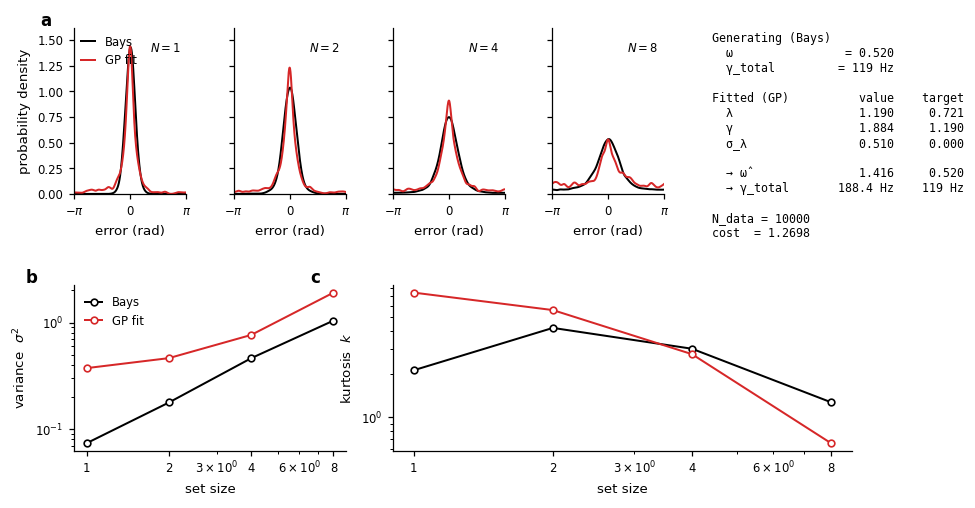

In [28]:
# === Plot: fitted GP (red) vs Bays-generated data (black) ===
# Top row:    error distributions per set size (KDE)
# Bottom row: variance (left) and kurtosis (right) vs set size
# Right column: parameter recovery summary
#
# Style: Nature-style scientific figure.  Sans-serif throughout, thin spines,
# left+bottom spines only, outward ticks, restrained palette.

import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ---- Style: applied locally via rcParams context ----
NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     8,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,   # embed fonts as TrueType (editable in Illustrator)
    'ps.fonttype':        42,
}

GP_COLOR   = '#D62728'    # Nature-style red
BAYS_COLOR = '#000000'    # black for reference data
BAND_ALPHA = 0.18

theta_smooth_fit = np.linspace(-np.pi, np.pi, 500)


def _style_axes(ax):
    """Apply consistent Nature-style touches to an axes."""
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


with mpl.rc_context(NATURE_STYLE):
    fig = plt.figure(figsize=(7.2, 4.4))
    gs = gridspec.GridSpec(
        2, len(SET_SIZES_BAYS) + 1,
        width_ratios=[1] * len(SET_SIZES_BAYS) + [1.25],
        hspace=0.55, wspace=0.40,
        left=0.07, right=0.97, bottom=0.12, top=0.92,
    )

    # ---- Row 1: error distributions per set size ----
    # Pre-compute KDEs to determine shared y-limit
    kdes_data = {}
    kdes_fit  = {}
    y_max = 0.0
    for N in SET_SIZES_BAYS:
        kdes_data[N] = vonmises_kde(data_errors[N],   theta_smooth_fit, kappa=KAPPA_BAYS_AC)
        kdes_fit[N]  = vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
        y_max = max(y_max, kdes_data[N].max(), kdes_fit[N].max())
    y_top = y_max * 1.12

    for i, N in enumerate(SET_SIZES_BAYS):
        ax = fig.add_subplot(gs[0, i])
        ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                label='Bays' if i == 0 else None)
        ax.plot(theta_smooth_fit, kdes_fit[N],  color=GP_COLOR,   lw=1.2,
                label='GP fit' if i == 0 else None)

        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(0, y_top)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        ax.set_xlabel('error (rad)')

        # Set-size label: small, top-right, inside axes
        ax.text(0.95, 0.92, f'$N={N}$', transform=ax.transAxes,
                fontsize=7, ha='right', va='top')

        # Shared y-axis treatment: only leftmost shows ticks/label
        if i == 0:
            ax.set_ylabel('probability density')
            ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                      borderaxespad=0.2)
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)

        # Panel letter "a" on the first panel only
        if i == 0:
            ax.text(-0.30, 1.10, 'a', transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top')

        _style_axes(ax)

    # ---- Top-right: parameter recovery summary ----
    ax_params = fig.add_subplot(gs[0, len(SET_SIZES_BAYS)])
    ax_params.axis('off')

    # Three-column aligned table.  Monospace for column alignment.
    txt_lines = [
        ('Generating (Bays)',  '',                                ''),
        ('  ω',                f'= {OMEGA_GEN:.3f}',              ''),
        ('  γ_total',          f'= {GAMMA_TOTAL_GEN:.0f} Hz',     ''),
        ('',                   '',                                ''),
        ('Fitted (GP)',        'value',                           'target'),
        ('  λ',                f'{lambda_hat:.3f}',               f'{LAMBDA_TARGET:.3f}'),
        ('  γ',                f'{gamma_hat:.3f}',                f'{GAMMA_TARGET:.3f}'),
        ('  σ_λ',              f'{sigma_lambda_hat:.3f}',         f'{SIGMA_LAMBDA_TARGET:.3f}'),
        ('',                   '',                                ''),
        ('  → ω̂',              f'{omega_hat:.3f}',                f'{OMEGA_GEN:.3f}'),
        ('  → γ_total',        f'{gamma_total_hat:.1f} Hz',       f'{GAMMA_TOTAL_GEN:.0f} Hz'),
        ('',                   '',                                ''),
        (f'N_data = {N_DATA}', '',                                ''),
        (f'cost  = {result.cost:.4f}', '',                        ''),
    ]
    # Render as one block of left-aligned monospace
    txt = '\n'.join(
        f'{a:<14}{b:>12}{c:>10}' if (b or c) else a
        for a, b, c in txt_lines
    )
    ax_params.text(0.0, 0.98, txt, transform=ax_params.transAxes,
                   fontsize=7, va='top', ha='left', family='monospace')

    # ---- Row 2: variance (left) and kurtosis (right) vs set size ----
    # Compute Bays moments per set size (from the synthetic data)
    var_bays  = np.array([circular_moments(data_errors[N])['variance']  for N in SET_SIZES_BAYS])
    kurt_bays = np.array([circular_moments(data_errors[N])['kurtosis']  for N in SET_SIZES_BAYS])
    var_fit   = np.array([circular_moments(fitted_errors[N])['variance']  for N in SET_SIZES_BAYS])
    kurt_fit  = np.array([circular_moments(fitted_errors[N])['kurtosis']  for N in SET_SIZES_BAYS])

    # Variance: log-log axes (Bays-style power law presentation)
    ax_var = fig.add_subplot(gs[1, :2])
    ax_var.plot(SET_SIZES_BAYS, var_bays, marker='o', color=BAYS_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, label='Bays')
    ax_var.plot(SET_SIZES_BAYS, var_fit,  marker='o', color=GP_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, label='GP fit')
    ax_var.set_xscale('log'); ax_var.set_yscale('log')
    ax_var.set_xticks(SET_SIZES_BAYS)
    ax_var.set_xticklabels([str(N) for N in SET_SIZES_BAYS])
    ax_var.set_xlabel('set size')
    ax_var.set_ylabel(r'variance  $\sigma^2$')
    ax_var.legend(loc='upper left', frameon=False, handlelength=1.5)
    ax_var.text(-0.18, 1.10, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    # Kurtosis: linear x, log y (matching Bays Fig 2f convention)
    ax_kurt = fig.add_subplot(gs[1, 2:])
    ax_kurt.plot(SET_SIZES_BAYS, kurt_bays, marker='o', color=BAYS_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, label='Bays')
    ax_kurt.plot(SET_SIZES_BAYS, kurt_fit,  marker='o', color=GP_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, label='GP fit')
    ax_kurt.set_xscale('log'); ax_kurt.set_yscale('log')
    ax_kurt.set_xticks(SET_SIZES_BAYS)
    ax_kurt.set_xticklabels([str(N) for N in SET_SIZES_BAYS])
    ax_kurt.set_xlabel('set size')
    ax_kurt.set_ylabel(r'kurtosis  $k$')
    ax_kurt.text(-0.18, 1.10, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)
    fig.savefig('gp_fit_overlay.png', dpi=300, bbox_inches='tight')
    fig.savefig('gp_fit_overlay.pdf', bbox_inches='tight') 
    plt.show()

## GP fit to Bays Data using the Gamma Distribution to Generate the Fits

In [ ]:
# === Gamma-sampler fit: (lambda, gamma, CV) recovery against Bays data ===
# Same fitting machinery as the folded-Normal case, but the GP forward model
# uses the Gamma sampler (method="gamma") where lengthscale_variability is
# interpreted as the COEFFICIENT OF VARIATION of the lengthscale distribution.
#
# Parameter order: [lambda_base, gamma_per_neuron, CV]

from scipy.optimize import least_squares

# --- Fit configuration (Gamma) ---
# Reuse N_DATA, N_TRIALS_FIT, BIN_EDGES, OMEGA_GEN, GAMMA_TOTAL_GEN, SEED_FIT
# from the earlier fit-config cell so this block stays self-contained.

X0_GAMMA  = [1.0,   2.0,   0.5]
LO_GAMMA  = [0.1,   0.1,   0.01]   # CV > 0 strictly: Gamma is undefined at CV=0
HI_GAMMA  = [3.0,   10.0,  10.0]
DIFF_STEP_GAMMA = 0.05

CV_TARGET = 0.0   # Bays is homogeneous; against Bays data we expect CV → small

print('Gamma-sampler fit:')
print(f'  x0     = {X0_GAMMA}  (lambda, gamma, CV)')
print(f'  bounds = ({LO_GAMMA}, {HI_GAMMA})')
print(f'  Note: CV lower bound is 0.01 (Gamma sampler undefined at CV=0)')
print()

# --- Step 1: synthetic dataset (reuses data_errors / data_vector if already
# computed in the folded-Normal fit cell; otherwise generates fresh) ---
if 'data_vector' not in globals():
    print('Generating Bays synthetic dataset...')
    data_errors = {}
    data_hists  = {}
    rng_data = np.random.RandomState(SEED_FIT)
    for N in SET_SIZES_BAYS:
        errs = bays_run_trials(
            n_trials=N_DATA, set_size=N,
            omega=OMEGA_GEN, gamma_total=GAMMA_TOTAL_GEN,
            T_d=T_D_BAYS, M=M_BAYS, rng=rng_data,
        )
        data_errors[N] = errs
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        data_hists[N] = h
    data_vector = np.concatenate([data_hists[N] for N in SET_SIZES_BAYS])
else:
    print('Reusing existing Bays synthetic dataset (data_vector).')


# --- Step 2: GP forward model with Gamma sampler ---
def gp_forward_gamma(lambda_base, gamma_per_neuron, cv, seed=0):
    """Run a GP sweep at (lambda_base, gamma_per_neuron, CV) using the Gamma
    sampler. Returns a histogram vector matching data_vector."""
    max_locs = max(SET_SIZES_BAYS)

    # method="gamma" overrides USE_GAMMA at the call site; lengthscale_variability
    # is interpreted as the CV of the Gamma distribution over lengthscales.
    population = generate_neuron_population(
        n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lambda_base,
        lengthscale_variability=cv,
        seed=seed,
        gain_variability=GAIN_VARIABILITY,
        method="gamma",
    )
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(max_locs)]

    pred_hists = []
    for N in SET_SIZES_BAYS:
        rng = np.random.RandomState(seed + N)
        errs = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


def residual_gamma(params):
    lam, gam, cv = params
    pred = gp_forward_gamma(lam, gam, cv, seed=SEED_FIT)
    return data_vector - pred


# --- Step 3: run the optimiser ---
t0 = time.time()
result_gamma = least_squares(
    residual_gamma, x0=X0_GAMMA, bounds=(LO_GAMMA, HI_GAMMA),
    method='trf', diff_step=DIFF_STEP_GAMMA, verbose=2,
)
print(f'\nGamma fit completed in {time.time()-t0:.1f}s')

lambda_hat_g, gamma_hat_g, cv_hat = result_gamma.x
omega_hat_g       = lambda_hat_g ** 2
gamma_total_hat_g = gamma_hat_g * M

print(f'\n=== Gamma fit results ===')
print(f'  lambda_hat   = {lambda_hat_g:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat    = {gamma_hat_g:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  CV_hat       = {cv_hat:.4f}    (target near 0; Bays is homogeneous)')
print(f'  -> omega_hat = {omega_hat_g:.4f}    (Bays generating value {OMEGA_GEN})')
print(f'  -> gamma_tot = {gamma_total_hat_g:.1f} Hz  '
      f'(Bays generating value {GAMMA_TOTAL_GEN})')
print(f'  final cost   = {result_gamma.cost:.6f}')

# --- Step 4: final predictions at fitted parameters for plotting ---
fitted_errors_gamma = {}
max_locs = max(SET_SIZES_BAYS)

population_fit_g = generate_neuron_population(
    n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
    base_lengthscale=lambda_hat_g,
    lengthscale_variability=cv_hat,
    seed=SEED_FIT,
    gain_variability=GAIN_VARIABILITY,
    method="gamma",
)
thetas_fit_g = population_fit_g[0]['orientations']
f_all_fit_g  = [np.array([population_fit_g[n]['f_samples'][loc, :] for n in range(M)])
                for loc in range(max_locs)]

for N in SET_SIZES_BAYS:
    rng = np.random.RandomState(SEED_FIT + 7000 + N)
    errs = run_multiloc_trials(
        f_all_fit_g, thetas_fit_g, tuple(range(N)), 0,
        gamma_hat_g, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    fitted_errors_gamma[N] = errs
    m = circular_moments(errs)
    print(f'  fitted N={N}: var={m["variance"]:.4f}  kurt={m["kurtosis"]:.3f}')

In [ ]:
# === Plot: fitted GP-Gamma (red) vs Bays-generated data (black) ===
# Mirrors the folded-Normal fit plot, but reports CV instead of sigma_lambda.

import matplotlib as mpl

NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     8,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR   = '#D62728'
BAYS_COLOR = '#000000'
theta_smooth_fit = np.linspace(-np.pi, np.pi, 500)


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


with mpl.rc_context(NATURE_STYLE):
    fig = plt.figure(figsize=(7.2, 4.4))
    gs = gridspec.GridSpec(
        2, len(SET_SIZES_BAYS) + 1,
        width_ratios=[1] * len(SET_SIZES_BAYS) + [1.25],
        hspace=0.55, wspace=0.40,
        left=0.07, right=0.97, bottom=0.12, top=0.92,
    )

    kdes_data = {}
    kdes_fit  = {}
    y_max = 0.0
    for N in SET_SIZES_BAYS:
        kdes_data[N] = vonmises_kde(data_errors[N],         theta_smooth_fit, kappa=KAPPA_BAYS_AC)
        kdes_fit[N]  = vonmises_kde(fitted_errors_gamma[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
        y_max = max(y_max, kdes_data[N].max(), kdes_fit[N].max())
    y_top = y_max * 1.12

    for i, N in enumerate(SET_SIZES_BAYS):
        ax = fig.add_subplot(gs[0, i])
        ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                label='Bays' if i == 0 else None)
        ax.plot(theta_smooth_fit, kdes_fit[N],  color=GP_COLOR,   lw=1.2,
                label='GP fit (Γ)' if i == 0 else None)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(0, y_top)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        ax.set_xlabel('error (rad)')
        ax.text(0.95, 0.92, f'$N={N}$', transform=ax.transAxes,
                fontsize=7, ha='right', va='top')
        if i == 0:
            ax.set_ylabel('probability density')
            ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                      borderaxespad=0.2)
            ax.text(-0.30, 1.10, 'a', transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        _style_axes(ax)

    ax_params = fig.add_subplot(gs[0, len(SET_SIZES_BAYS)])
    ax_params.axis('off')
    txt_lines = [
        ('Generating (Bays)',           '',                                ''),
        ('  ω',                         f'= {OMEGA_GEN:.3f}',              ''),
        ('  γ_total',                   f'= {GAMMA_TOTAL_GEN:.0f} Hz',     ''),
        ('',                            '',                                ''),
        ('Fitted (GP-Γ)',               'value',                           'target'),
        ('  λ',                         f'{lambda_hat_g:.3f}',             f'{LAMBDA_TARGET:.3f}'),
        ('  γ',                         f'{gamma_hat_g:.3f}',              f'{GAMMA_TARGET:.3f}'),
        ('  CV',                        f'{cv_hat:.3f}',                   '~0'),
        ('',                            '',                                ''),
        ('  → ω̂',                       f'{omega_hat_g:.3f}',              f'{OMEGA_GEN:.3f}'),
        ('  → γ_total',                 f'{gamma_total_hat_g:.1f} Hz',     f'{GAMMA_TOTAL_GEN:.0f} Hz'),
        ('',                            '',                                ''),
        (f'N_data = {N_DATA}',          '',                                ''),
        (f'cost  = {result_gamma.cost:.4f}', '',                           ''),
    ]
    txt = '\n'.join(
        f'{a:<14}{b:>12}{c:>10}' if (b or c) else a
        for a, b, c in txt_lines
    )
    ax_params.text(0.0, 0.98, txt, transform=ax_params.transAxes,
                   fontsize=7, va='top', ha='left', family='monospace')

    var_bays  = np.array([circular_moments(data_errors[N])['variance']         for N in SET_SIZES_BAYS])
    kurt_bays = np.array([circular_moments(data_errors[N])['kurtosis']         for N in SET_SIZES_BAYS])
    var_fit   = np.array([circular_moments(fitted_errors_gamma[N])['variance'] for N in SET_SIZES_BAYS])
    kurt_fit  = np.array([circular_moments(fitted_errors_gamma[N])['kurtosis'] for N in SET_SIZES_BAYS])

    ax_var = fig.add_subplot(gs[1, :2])
    ax_var.plot(SET_SIZES_BAYS, var_bays, marker='o', color=BAYS_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, label='Bays')
    ax_var.plot(SET_SIZES_BAYS, var_fit,  marker='o', color=GP_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, label='GP fit (Γ)')
    ax_var.set_xscale('log'); ax_var.set_yscale('log')
    ax_var.set_xticks(SET_SIZES_BAYS)
    ax_var.set_xticklabels([str(N) for N in SET_SIZES_BAYS])
    ax_var.set_xlabel('set size')
    ax_var.set_ylabel(r'variance  $\sigma^2$')
    ax_var.legend(loc='upper left', frameon=False, handlelength=1.5)
    ax_var.text(-0.18, 1.10, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    ax_kurt = fig.add_subplot(gs[1, 2:])
    ax_kurt.plot(SET_SIZES_BAYS, kurt_bays, marker='o', color=BAYS_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, label='Bays')
    ax_kurt.plot(SET_SIZES_BAYS, kurt_fit,  marker='o', color=GP_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, label='GP fit (Γ)')
    ax_kurt.set_xscale('log'); ax_kurt.set_yscale('log')
    ax_kurt.set_xticks(SET_SIZES_BAYS)
    ax_kurt.set_xticklabels([str(N) for N in SET_SIZES_BAYS])
    ax_kurt.set_xlabel('set size')
    ax_kurt.set_ylabel(r'kurtosis  $k$')
    ax_kurt.text(-0.18, 1.10, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    fig.savefig('gp_gamma_fit_overlay.png', dpi=300, bbox_inches='tight')
    fig.savefig('gp_gamma_fit_overlay.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
# === Fixed-CV sweep: six (lambda, gamma) fits at CV ∈ {0.1, 0.5, 1, 2, 5, 10} ===
# At each fixed CV value, fit ONLY lambda and gamma. CV is held constant inside
# the forward model. Produces six independent fits so we can see how recovery
# quality varies with the imposed level of lengthscale heterogeneity.

from scipy.optimize import least_squares

# --- Sweep configuration ---
CV_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# Two-parameter fit setup (CV is fixed per run)
X0_FIXED  = [1.0,   2.0]
LO_FIXED  = [0.1,   0.1]
HI_FIXED  = [3.0,   10.0]
DIFF_STEP_FIXED = 0.05

print(f'Fixed-CV sweep: CV ∈ {CV_VALUES}')
print(f'  Per-CV fit: x0={X0_FIXED}, bounds=({LO_FIXED}, {HI_FIXED})')
print()

# --- Reuse Bays synthetic dataset if available; otherwise generate ---
if 'data_vector' not in globals():
    print('Generating Bays synthetic dataset...')
    data_errors = {}
    data_hists  = {}
    rng_data = np.random.RandomState(SEED_FIT)
    for N in SET_SIZES_BAYS:
        errs = bays_run_trials(
            n_trials=N_DATA, set_size=N,
            omega=OMEGA_GEN, gamma_total=GAMMA_TOTAL_GEN,
            T_d=T_D_BAYS, M=M_BAYS, rng=rng_data,
        )
        data_errors[N] = errs
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        data_hists[N] = h
    data_vector = np.concatenate([data_hists[N] for N in SET_SIZES_BAYS])
else:
    print('Reusing existing Bays synthetic dataset.')


# --- Forward model factory: builds a residual function with CV baked in ---
def make_residual(cv_fixed):
    def gp_forward_fixed(lambda_base, gamma_per_neuron, seed=0):
        max_locs = max(SET_SIZES_BAYS)
        population = generate_neuron_population(
            n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
            base_lengthscale=lambda_base,
            lengthscale_variability=cv_fixed,
            seed=seed,
            gain_variability=GAIN_VARIABILITY,
            method="gamma",
        )
        thetas = population[0]['orientations']
        f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
                 for loc in range(max_locs)]
        pred_hists = []
        for N in SET_SIZES_BAYS:
            rng = np.random.RandomState(seed + N)
            errs = run_multiloc_trials(
                f_all, thetas, tuple(range(N)), 0,
                gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
            h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
            pred_hists.append(h)
        return np.concatenate(pred_hists)

    def residual(params):
        lam, gam = params
        return data_vector - gp_forward_fixed(lam, gam, seed=SEED_FIT)

    return residual, gp_forward_fixed


# --- Run a fit per CV value ---
sweep_results = {}   # cv -> dict(lambda_hat, gamma_hat, cost, fitted_errors)

for cv in CV_VALUES:
    print(f'\n--- CV = {cv} ---')
    t0 = time.time()
    residual_fn, forward_fn = make_residual(cv)

    result = least_squares(
        residual_fn, x0=X0_FIXED, bounds=(LO_FIXED, HI_FIXED),
        method='trf', diff_step=DIFF_STEP_FIXED, verbose=0,
    )
    lam_hat, gam_hat = result.x
    print(f'  lambda_hat = {lam_hat:.4f},  gamma_hat = {gam_hat:.4f},  '
          f'cost = {result.cost:.4f},  time = {time.time()-t0:.1f}s')

    # Final predictions at the fitted (lambda, gamma) with this CV
    max_locs = max(SET_SIZES_BAYS)
    population_fit = generate_neuron_population(
        n_neurons=M, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lam_hat,
        lengthscale_variability=cv,
        seed=SEED_FIT,
        gain_variability=GAIN_VARIABILITY,
        method="gamma",
    )
    thetas_fit = population_fit[0]['orientations']
    f_all_fit  = [np.array([population_fit[n]['f_samples'][loc, :] for n in range(M)])
                  for loc in range(max_locs)]

    fitted_errors = {}
    for N in SET_SIZES_BAYS:
        rng = np.random.RandomState(SEED_FIT + 7000 + N)
        errs = run_multiloc_trials(
            f_all_fit, thetas_fit, tuple(range(N)), 0,
            gam_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        fitted_errors[N] = errs

    sweep_results[cv] = {
        'lambda_hat':    lam_hat,
        'gamma_hat':     gam_hat,
        'omega_hat':     lam_hat ** 2,
        'gamma_total':   gam_hat * M,
        'cost':          result.cost,
        'fitted_errors': fitted_errors,
    }

print('\n=== Sweep summary ===')
print(f'{"CV":>6}  {"λ̂":>8}  {"γ̂":>8}  {"ω̂":>8}  {"γ_total":>10}  {"cost":>8}')
for cv in CV_VALUES:
    r = sweep_results[cv]
    print(f'{cv:>6.2f}  {r["lambda_hat"]:>8.4f}  {r["gamma_hat"]:>8.4f}  '
          f'{r["omega_hat"]:>8.4f}  {r["gamma_total"]:>10.2f}  {r["cost"]:>8.4f}')

In [ ]:
# === Plot: fixed-CV sweep, one figure per CV value ===
# Mirrors the fitted-GP figure layout, but reports a fixed CV (not fitted).
# Each figure is saved as gp_cv{cv}_fit.png/pdf for easy reference.

import matplotlib as mpl

NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     8,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR   = '#D62728'
BAYS_COLOR = '#000000'
theta_smooth_fit = np.linspace(-np.pi, np.pi, 500)


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def plot_cv_fit(cv, result, save_prefix='gp_cv'):
    """Render one figure for a single fixed-CV fit."""
    fitted_errors = result['fitted_errors']
    lam_hat = result['lambda_hat']
    gam_hat = result['gamma_hat']
    omega_hat = result['omega_hat']
    gamma_total_hat = result['gamma_total']
    cost = result['cost']

    with mpl.rc_context(NATURE_STYLE):
        fig = plt.figure(figsize=(7.2, 4.4))
        gs = gridspec.GridSpec(
            2, len(SET_SIZES_BAYS) + 1,
            width_ratios=[1] * len(SET_SIZES_BAYS) + [1.25],
            hspace=0.55, wspace=0.40,
            left=0.07, right=0.97, bottom=0.12, top=0.88,
        )

        # ---- Row 1: error distributions ----
        kdes_data = {}
        kdes_fit  = {}
        y_max = 0.0
        for N in SET_SIZES_BAYS:
            kdes_data[N] = vonmises_kde(data_errors[N],   theta_smooth_fit, kappa=KAPPA_BAYS_AC)
            kdes_fit[N]  = vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
            y_max = max(y_max, kdes_data[N].max(), kdes_fit[N].max())
        y_top = y_max * 1.12

        for i, N in enumerate(SET_SIZES_BAYS):
            ax = fig.add_subplot(gs[0, i])
            ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                    label='Bays' if i == 0 else None)
            ax.plot(theta_smooth_fit, kdes_fit[N],  color=GP_COLOR,   lw=1.2,
                    label='GP fit' if i == 0 else None)
            ax.set_xlim(-np.pi, np.pi)
            ax.set_ylim(0, y_top)
            ax.set_xticks([-np.pi, 0, np.pi])
            ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
            ax.set_xlabel('error (rad)')
            ax.text(0.95, 0.92, f'$N={N}$', transform=ax.transAxes,
                    fontsize=7, ha='right', va='top')
            if i == 0:
                ax.set_ylabel('probability density')
                ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                          borderaxespad=0.2)
                ax.text(-0.30, 1.10, 'a', transform=ax.transAxes,
                        fontsize=10, fontweight='bold', va='top')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            _style_axes(ax)

        # ---- Top-right: parameter summary ----
        ax_params = fig.add_subplot(gs[0, len(SET_SIZES_BAYS)])
        ax_params.axis('off')
        txt_lines = [
            ('Generating (Bays)',         '',                              ''),
            ('  ω',                       f'= {OMEGA_GEN:.3f}',            ''),
            ('  γ_total',                 f'= {GAMMA_TOTAL_GEN:.0f} Hz',   ''),
            ('',                          '',                              ''),
            ('Fitted (GP-Γ)',             'value',                         'target'),
            ('  λ',                       f'{lam_hat:.3f}',                f'{LAMBDA_TARGET:.3f}'),
            ('  γ',                       f'{gam_hat:.3f}',                f'{GAMMA_TARGET:.3f}'),
            ('  CV (fixed)',              f'{cv:.2f}',                     '—'),
            ('',                          '',                              ''),
            ('  → ω̂',                     f'{omega_hat:.3f}',              f'{OMEGA_GEN:.3f}'),
            ('  → γ_total',               f'{gamma_total_hat:.1f} Hz',     f'{GAMMA_TOTAL_GEN:.0f} Hz'),
            ('',                          '',                              ''),
            (f'N_data = {N_DATA}',        '',                              ''),
            (f'cost  = {cost:.4f}',       '',                              ''),
        ]
        txt = '\n'.join(
            f'{a:<14}{b:>12}{c:>10}' if (b or c) else a
            for a, b, c in txt_lines
        )
        ax_params.text(0.0, 0.98, txt, transform=ax_params.transAxes,
                       fontsize=7, va='top', ha='left', family='monospace')

        # ---- Row 2: variance and kurtosis ----
        var_bays  = np.array([circular_moments(data_errors[N])['variance']   for N in SET_SIZES_BAYS])
        kurt_bays = np.array([circular_moments(data_errors[N])['kurtosis']   for N in SET_SIZES_BAYS])
        var_fit   = np.array([circular_moments(fitted_errors[N])['variance'] for N in SET_SIZES_BAYS])
        kurt_fit  = np.array([circular_moments(fitted_errors[N])['kurtosis'] for N in SET_SIZES_BAYS])

        ax_var = fig.add_subplot(gs[1, :2])
        ax_var.plot(SET_SIZES_BAYS, var_bays, marker='o', color=BAYS_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0, label='Bays')
        ax_var.plot(SET_SIZES_BAYS, var_fit,  marker='o', color=GP_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0, label='GP fit')
        ax_var.set_xscale('log'); ax_var.set_yscale('log')
        ax_var.set_xticks(SET_SIZES_BAYS)
        ax_var.set_xticklabels([str(N) for N in SET_SIZES_BAYS])
        ax_var.set_xlabel('set size')
        ax_var.set_ylabel(r'variance  $\sigma^2$')
        ax_var.legend(loc='upper left', frameon=False, handlelength=1.5)
        ax_var.text(-0.18, 1.10, 'b', transform=ax_var.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_var)

        ax_kurt = fig.add_subplot(gs[1, 2:])
        ax_kurt.plot(SET_SIZES_BAYS, kurt_bays, marker='o', color=BAYS_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0, label='Bays')
        ax_kurt.plot(SET_SIZES_BAYS, kurt_fit,  marker='o', color=GP_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0, label='GP fit')
        ax_kurt.set_xscale('log'); ax_kurt.set_yscale('log')
        ax_kurt.set_xticks(SET_SIZES_BAYS)
        ax_kurt.set_xticklabels([str(N) for N in SET_SIZES_BAYS])
        ax_kurt.set_xlabel('set size')
        ax_kurt.set_ylabel(r'kurtosis  $k$')
        ax_kurt.text(-0.18, 1.10, 'c', transform=ax_kurt.transAxes,
                     fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_kurt)

        # Title with CV value for clarity
        fig.suptitle(f'GP-Γ fit at fixed CV = {cv}',
                     fontsize=9, y=0.98)

        # Save with CV in filename (replace '.' with 'p' for filesystem safety)
        cv_tag = str(cv).replace('.', 'p')
        fig.savefig(f'{save_prefix}_{cv_tag}_fit.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_prefix}_{cv_tag}_fit.pdf', bbox_inches='tight')
        plt.show()


# --- Render one figure per CV value ---
for cv in CV_VALUES:
    print(f'\nPlotting CV = {cv} ...')
    plot_cv_fit(cv, sweep_results[cv])